# 01 — Exploratory Data Analysis
### Ames Housing Dataset

Before any modeling, we need to deeply understand the data. This notebook covers:

1. Dataset overview and basic statistics
2. Target variable analysis (SalePrice)
3. Missing value audit
4. Numerical feature distributions and outlier detection
5. Categorical feature analysis
6. Correlation analysis with statistical tests
7. Neighborhood deep-dive
8. Time trends (YearBuilt, YrSold)
9. Key EDA findings summary

**Dataset:** 1,460 training samples · 79 features · Ames, Iowa 2006–2010

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../plots', exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
})
C = ['#4C6EF5','#F76707','#2F9E44','#E03131','#7950F2','#1098AD','#F59F00','#364FC7']

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head(3)

Train: (1460, 81)  |  Test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 1. Dataset Overview

In [2]:
numeric_cols = train.select_dtypes(include=np.number).columns.drop('Id').tolist()
cat_cols     = train.select_dtypes(include='object').columns.tolist()
print(f'Numeric features:     {len(numeric_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Total rows:           {len(train)}')
print(f'\nMemory usage: {train.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'\nSalePrice range: ${train.SalePrice.min():,} – ${train.SalePrice.max():,}')
print(f'SalePrice mean:  ${train.SalePrice.mean():,.0f}')
print(f'SalePrice median:${train.SalePrice.median():,.0f}')

Numeric features:     37
Categorical features: 43
Total rows:           1460

Memory usage: 3948.5 KB

SalePrice range: $34,900 – $755,000
SalePrice mean:  $180,921
SalePrice median:$163,000


## 2. Target Variable — SalePrice

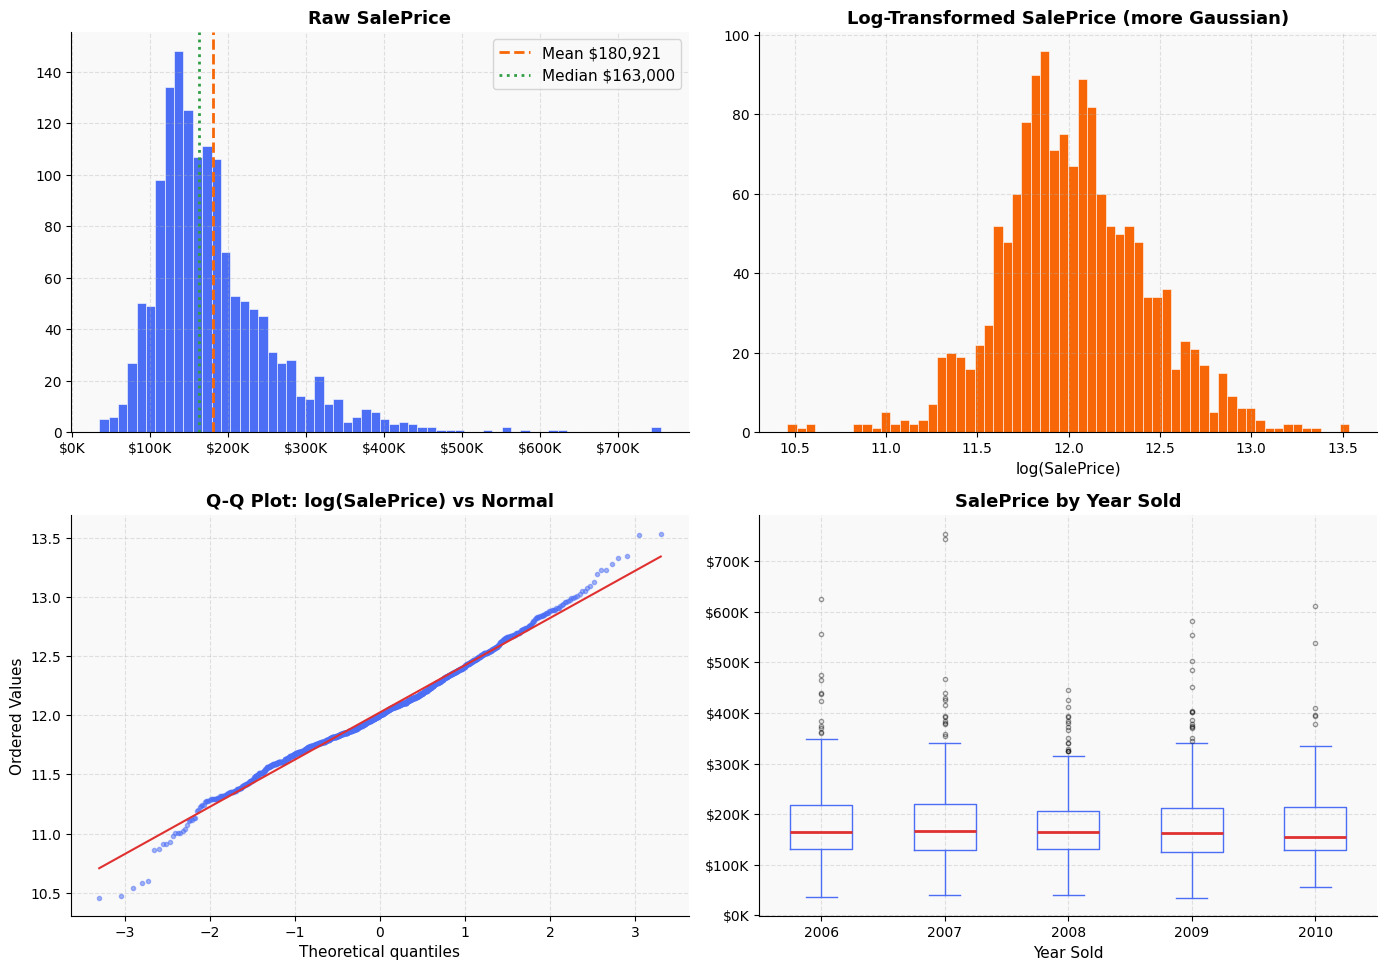

Normality test (D'Agostino-Pearson):
  Raw:              stat=610.84, p=2.28e-133  → NOT normal
  Log-transformed:  stat=25.51, p=2.89e-06  → NOT normal

Skewness:  raw=1.881  log=0.121
Kurtosis:  raw=6.510  log=0.803


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SalePrice Distribution Analysis', fontsize=15, fontweight='bold')

# Raw histogram
axes[0,0].hist(train.SalePrice, bins=60, color=C[0], edgecolor='white', lw=0.4)
axes[0,0].axvline(train.SalePrice.mean(),   color=C[1], lw=2, linestyle='--', label=f'Mean ${train.SalePrice.mean():,.0f}')
axes[0,0].axvline(train.SalePrice.median(), color=C[2], lw=2, linestyle=':',  label=f'Median ${train.SalePrice.median():,.0f}')
axes[0,0].set_title('Raw SalePrice')
axes[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0,0].legend()

# Log-transformed histogram
log_price = np.log1p(train.SalePrice)
axes[0,1].hist(log_price, bins=60, color=C[1], edgecolor='white', lw=0.4)
axes[0,1].set_title('Log-Transformed SalePrice (more Gaussian)')
axes[0,1].set_xlabel('log(SalePrice)')

# Q-Q plot (normality test)
stats.probplot(log_price, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot: log(SalePrice) vs Normal')
axes[1,0].get_lines()[0].set(color=C[0], markersize=3, alpha=0.5)
axes[1,0].get_lines()[1].set(color=C[3], lw=1.5)

# Box plot by year sold
train.boxplot(column='SalePrice', by='YrSold', ax=axes[1,1],
              boxprops=dict(color=C[0]), medianprops=dict(color=C[3], lw=2),
              whiskerprops=dict(color=C[0]), capprops=dict(color=C[0]),
              flierprops=dict(marker='o', markersize=3, alpha=0.4, color=C[1]))
axes[1,1].set_title('SalePrice by Year Sold')
axes[1,1].set_xlabel('Year Sold')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
plt.suptitle('')

plt.tight_layout()
plt.savefig('../plots/01_target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Normality tests
stat_raw, p_raw = stats.normaltest(train.SalePrice)
stat_log, p_log = stats.normaltest(log_price)
print(f'Normality test (D\'Agostino-Pearson):')
print(f'  Raw:              stat={stat_raw:.2f}, p={p_raw:.2e}  → {"NOT normal" if p_raw < 0.05 else "Normal"}')
print(f'  Log-transformed:  stat={stat_log:.2f}, p={p_log:.2e}  → {"NOT normal" if p_log < 0.05 else "Normal"}')
print(f'\nSkewness:  raw={stats.skew(train.SalePrice):.3f}  log={stats.skew(log_price):.3f}')
print(f'Kurtosis:  raw={stats.kurtosis(train.SalePrice):.3f}  log={stats.kurtosis(log_price):.3f}')

## 3. Missing Value Audit

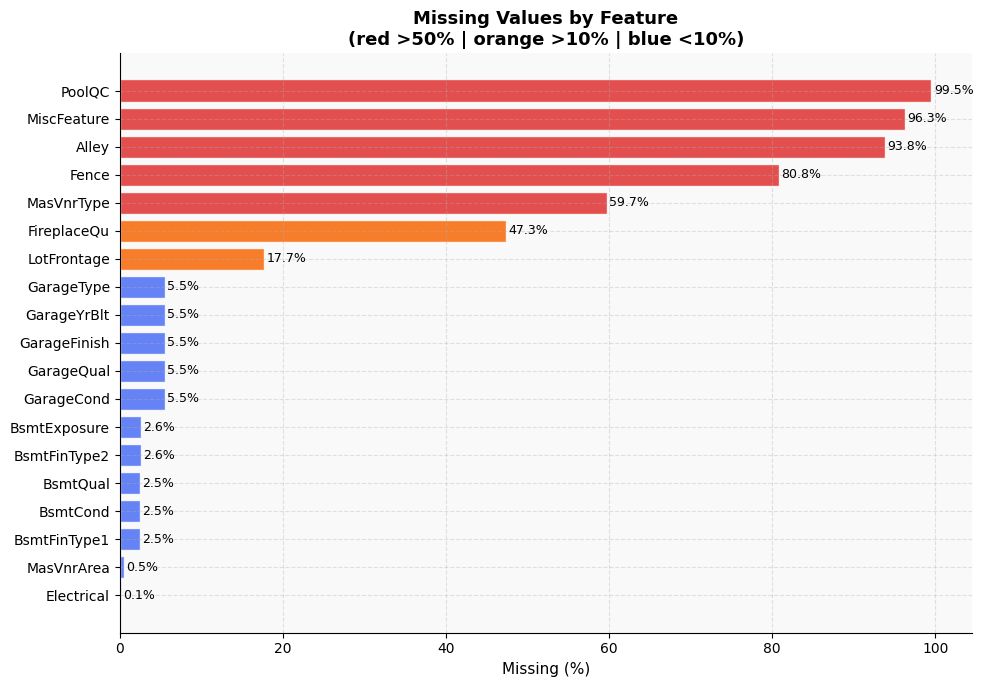

Top missing features and their interpretation:
  PoolQC            99.5%  →  NA = No Pool (96.9%)
  MiscFeature       96.3%  →  NA = No misc feature
  Alley             93.8%  →  NA = No alley access
  Fence             80.8%  →  NA = No fence
  MasVnrType        59.7%  →  Investigate further
  FireplaceQu       47.3%  →  NA = No fireplace
  LotFrontage       17.7%  →  Genuinely missing — impute by neighborhood median
  GarageType         5.5%  →  NA = No garage
  GarageYrBlt        5.5%  →  Investigate further
  GarageFinish       5.5%  →  NA = No garage


In [4]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

# Domain explanations for top missing columns
explanations = {
    'PoolQC':      'NA = No Pool (96.9%)',
    'MiscFeature': 'NA = No misc feature',
    'Alley':       'NA = No alley access',
    'Fence':       'NA = No fence',
    'FireplaceQu': 'NA = No fireplace',
    'LotFrontage': 'Genuinely missing — impute by neighborhood median',
    'GarageType':  'NA = No garage',
    'GarageFinish':'NA = No garage',
    'GarageQual':  'NA = No garage',
    'GarageCond':  'NA = No garage',
}

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [C[3] if p > 50 else C[1] if p > 10 else C[0] for p in missing_pct.values]
bars = ax.barh(missing.index[::-1], missing_pct.values[::-1], color=colors_bar[::-1], edgecolor='white', alpha=0.85)
for bar, pct in zip(bars, missing_pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature\n(red >50% | orange >10% | blue <10%)')
plt.tight_layout()
plt.savefig('../plots/02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top missing features and their interpretation:')
for col, pct in missing_pct.head(10).items():
    exp = explanations.get(col, 'Investigate further')
    print(f'  {col:15s}  {pct:5.1f}%  →  {exp}')

## 4. Numerical Features — Distributions & Outliers

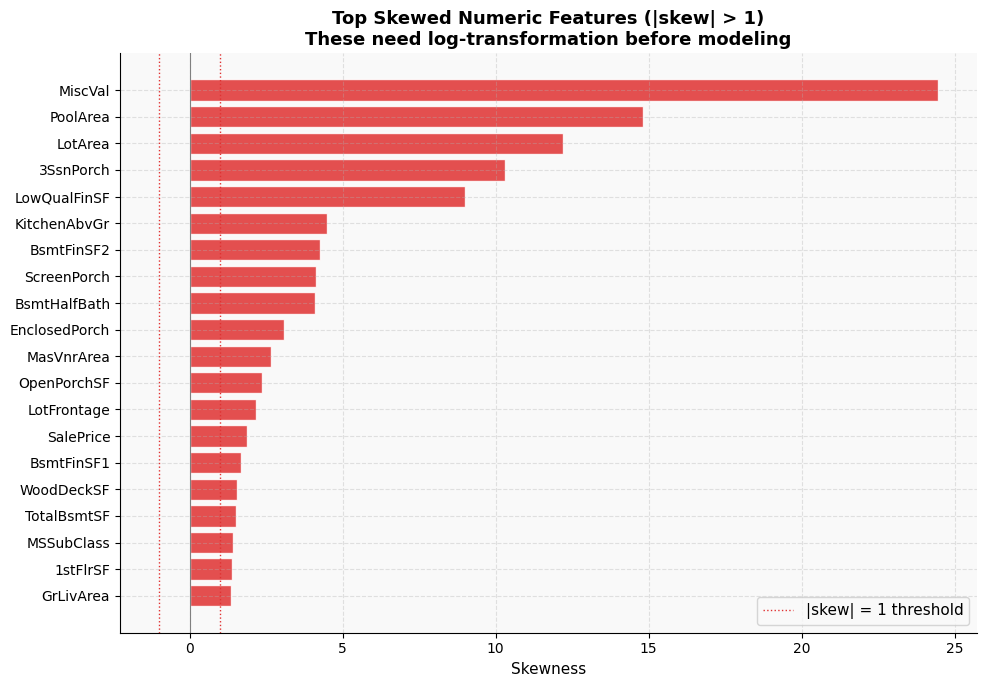

20 features with |skew| > 1 — will apply log1p transformation in preprocessing


In [5]:
# Skewness of all numeric features
num_df = train[numeric_cols].copy()
skew_vals = num_df.apply(lambda x: stats.skew(x.dropna())).sort_values(ascending=False)
high_skew = skew_vals[abs(skew_vals) > 1].head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_sk = [C[3] if v > 0 else C[0] for v in high_skew.values]
ax.barh(high_skew.index[::-1], high_skew.values[::-1], color=colors_sk[::-1], edgecolor='white', alpha=0.85)
ax.axvline(0,  color='gray', lw=0.8)
ax.axvline(1,  color=C[3], lw=1, linestyle=':', label='|skew| = 1 threshold')
ax.axvline(-1, color=C[3], lw=1, linestyle=':')
ax.set_xlabel('Skewness')
ax.set_title('Top Skewed Numeric Features (|skew| > 1)\nThese need log-transformation before modeling')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/03_feature_skewness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'{len(high_skew)} features with |skew| > 1 — will apply log1p transformation in preprocessing')

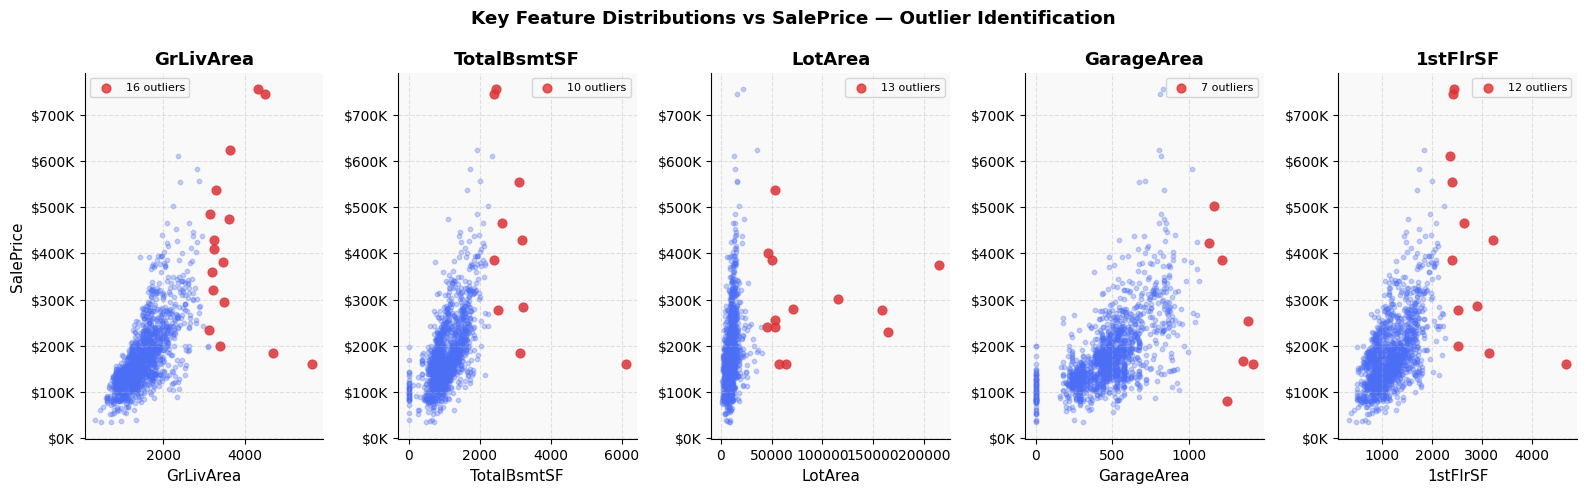

Note: Large houses with very low SalePrice (GrLivArea > 4000, SalePrice < $200K) are likely non-market sales.
The Kaggle competition notes to remove these 2 points for better generalization.


In [6]:
# Outlier detection for key continuous features
key_features = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea', '1stFlrSF']

fig, axes = plt.subplots(1, len(key_features), figsize=(16, 5))
fig.suptitle('Key Feature Distributions vs SalePrice — Outlier Identification', fontweight='bold')

for ax, feat in zip(axes, key_features):
    ax.scatter(train[feat], train['SalePrice'], alpha=0.3, s=10, color=C[0])
    # Mark outliers (beyond 3 SD)
    z = np.abs(stats.zscore(train[feat].fillna(0)))
    outlier_mask = z > 3
    ax.scatter(train.loc[outlier_mask, feat], train.loc[outlier_mask, 'SalePrice'],
               alpha=0.8, s=40, color=C[3], zorder=5, label=f'{outlier_mask.sum()} outliers')
    ax.set_xlabel(feat)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
    ax.set_title(feat)
    ax.legend(fontsize=8)

axes[0].set_ylabel('SalePrice')
plt.tight_layout()
plt.savefig('../plots/04_outlier_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Large houses with very low SalePrice (GrLivArea > 4000, SalePrice < $200K) are likely non-market sales.')
print('The Kaggle competition notes to remove these 2 points for better generalization.')

## 5. Correlation Analysis

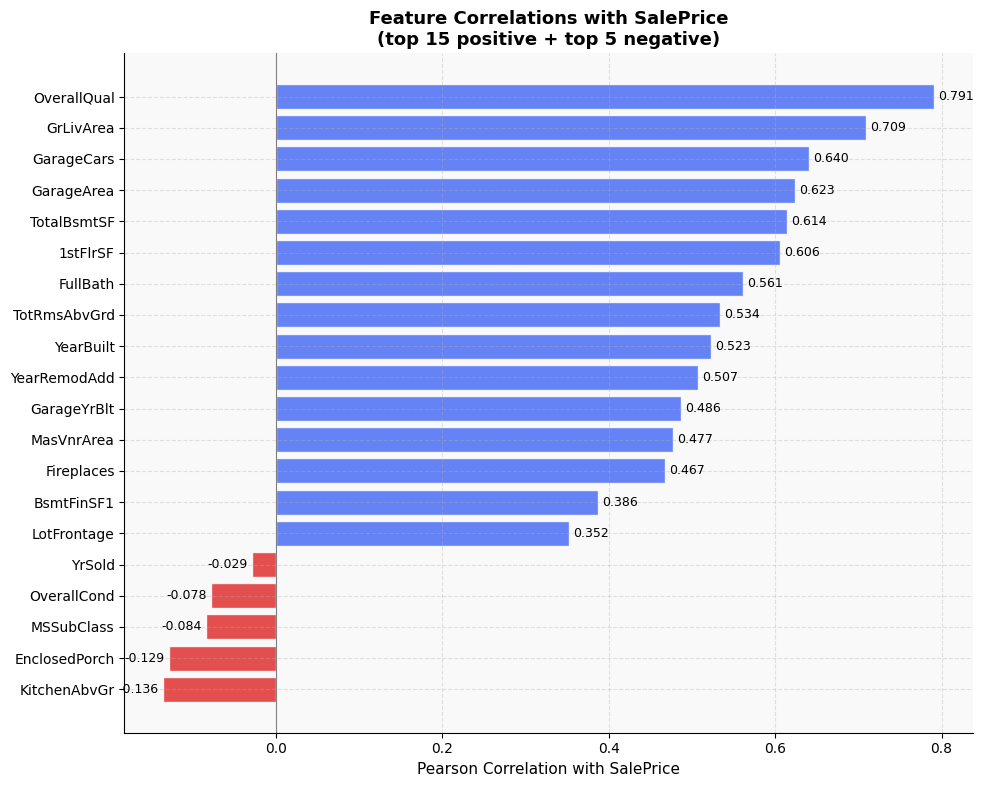

In [8]:
# Top correlated features with SalePrice
# Explicitly exclude SalePrice and Id here to be safe
safe_numeric = train.select_dtypes(include=np.number).columns.drop(['Id', 'SalePrice'], errors='ignore').tolist()

corr = train[safe_numeric].corrwith(train['SalePrice'])  # returns a Series, always
corr_sorted = corr.sort_values()
top15_pos = corr_sorted.tail(15)
top5_neg  = corr_sorted.head(5)
top_corr  = pd.concat([top5_neg, top15_pos])

fig, ax = plt.subplots(figsize=(10, 8))
colors_corr = [C[3] if v < 0 else C[0] for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors_corr, edgecolor='white', alpha=0.85)
ax.axvline(0, color='gray', lw=0.8)
for i, v in enumerate(top_corr.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i,
            f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_xlabel('Pearson Correlation with SalePrice')
ax.set_title('Feature Correlations with SalePrice\n(top 15 positive + top 5 negative)')
plt.tight_layout()
plt.savefig('../plots/05_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

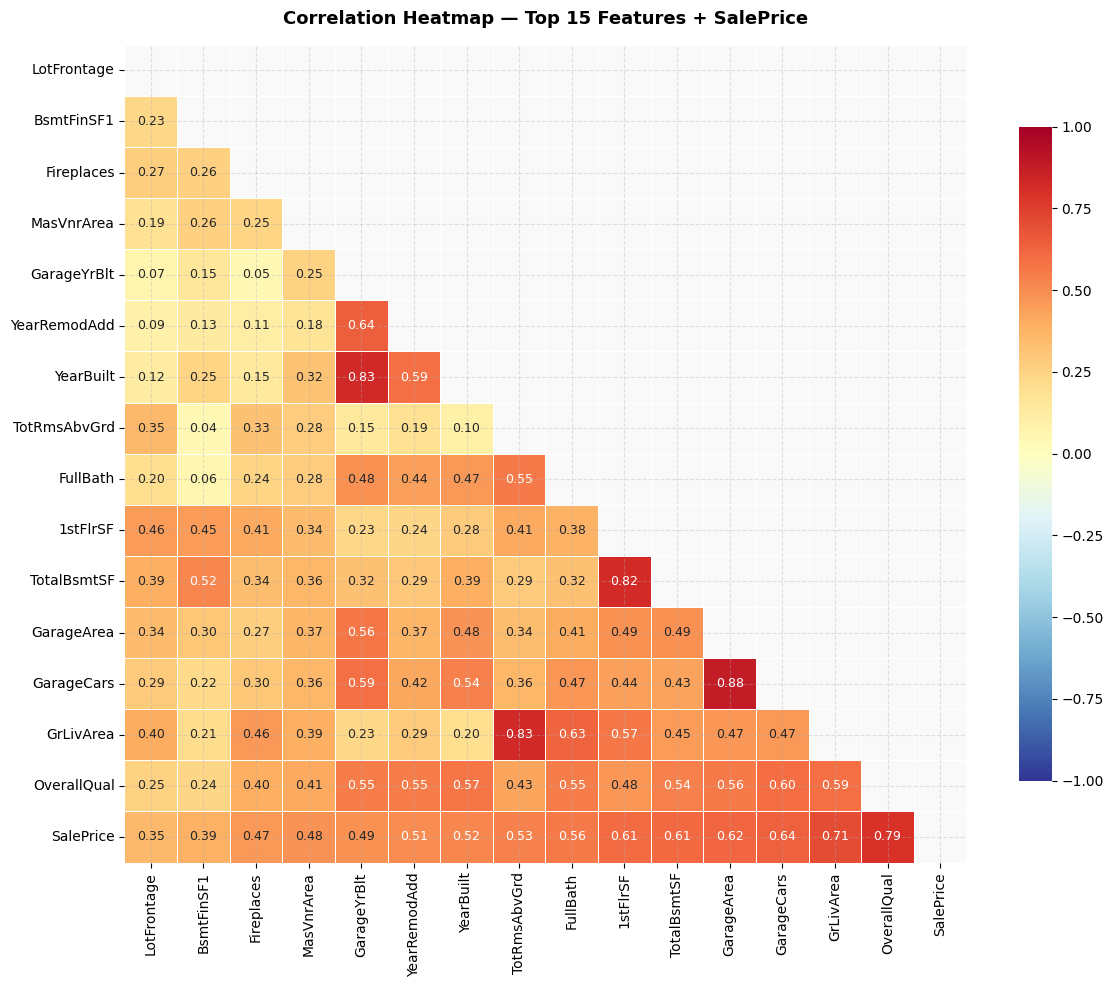

Note: GarageCars and GarageArea (r=0.88) are highly collinear — one may be redundant.
TotRmsAbvGrd and GrLivArea (r=0.83) similarly correlated.


In [9]:
# Correlation heatmap — top 15 features
top15_feats = corr_sorted.tail(15).index.tolist() + ['SalePrice']
corr_matrix = train[top15_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax,
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Top 15 Features + SalePrice', pad=15)
plt.tight_layout()
plt.savefig('../plots/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: GarageCars and GarageArea (r=0.88) are highly collinear — one may be redundant.')
print('TotRmsAbvGrd and GrLivArea (r=0.83) similarly correlated.')

## 6. Categorical Features

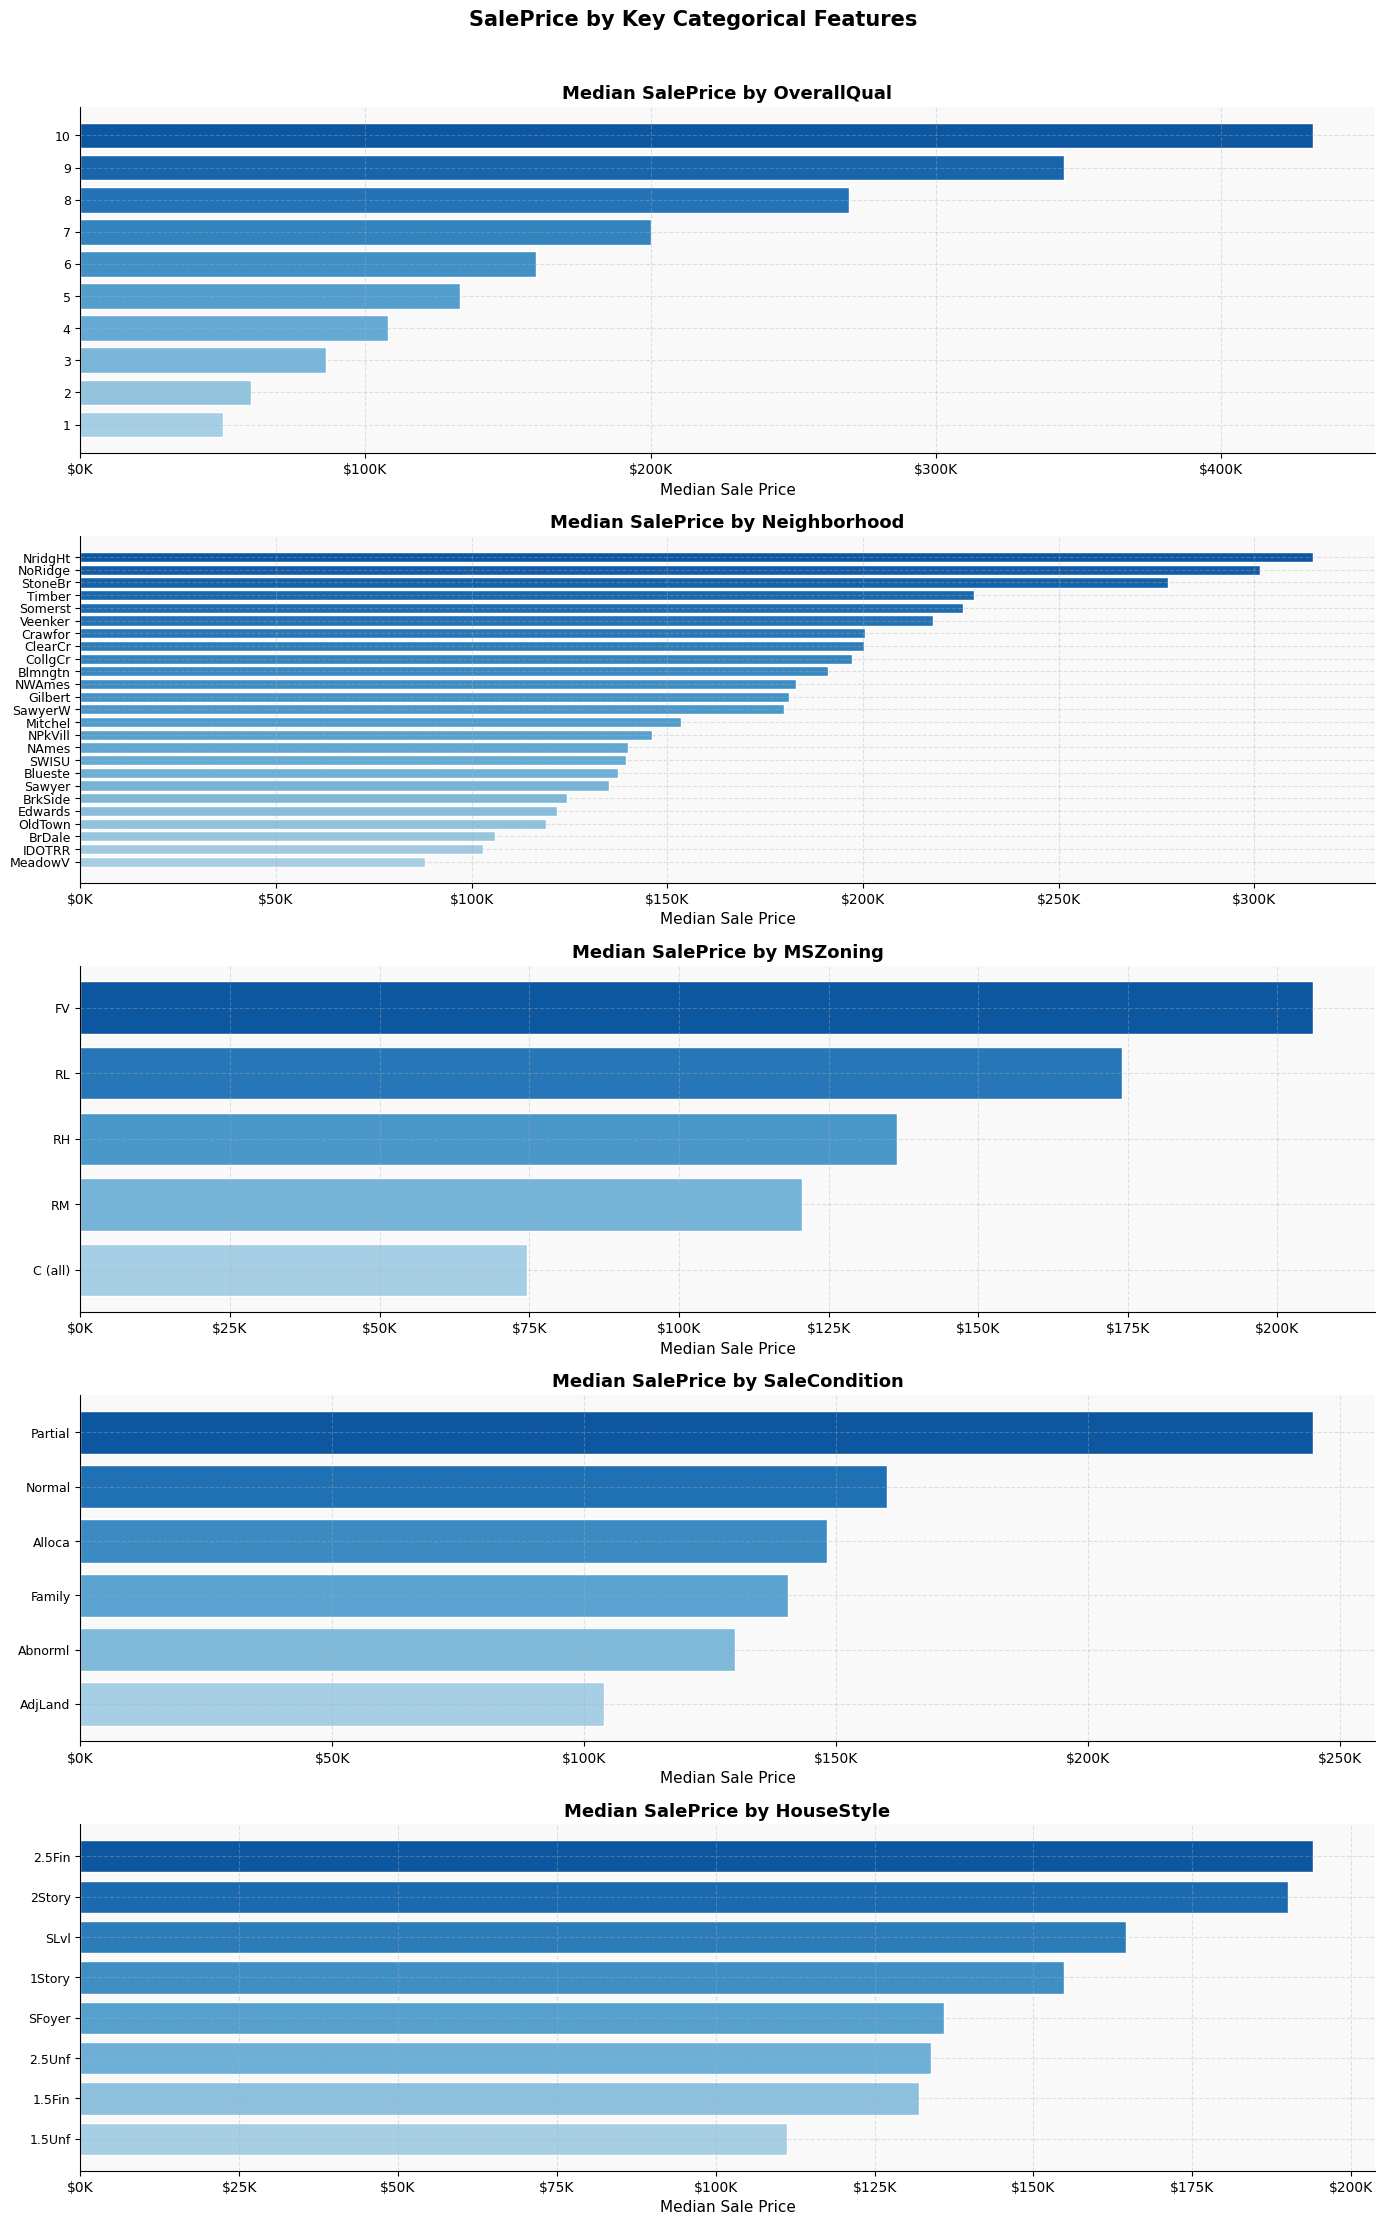

In [10]:
# Most impactful categorical features — median price by category
key_cats = ['OverallQual', 'Neighborhood', 'MSZoning', 'SaleCondition', 'HouseStyle']

fig, axes = plt.subplots(len(key_cats), 1, figsize=(14, 22))
fig.suptitle('SalePrice by Key Categorical Features', fontsize=15, fontweight='bold', y=1.01)

for ax, feat in zip(axes, key_cats):
    order = train.groupby(feat)['SalePrice'].median().sort_values().index
    medians = train.groupby(feat)['SalePrice'].median().loc[order]
    colors_cat = plt.cm.Blues(np.linspace(0.35, 0.85, len(order)))
    bars = ax.barh(range(len(order)), medians.values, color=colors_cat, edgecolor='white')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
    ax.set_title(f'Median SalePrice by {feat}')
    ax.set_xlabel('Median Sale Price')

plt.tight_layout()
plt.savefig('../plots/07_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Neighborhood Deep-Dive

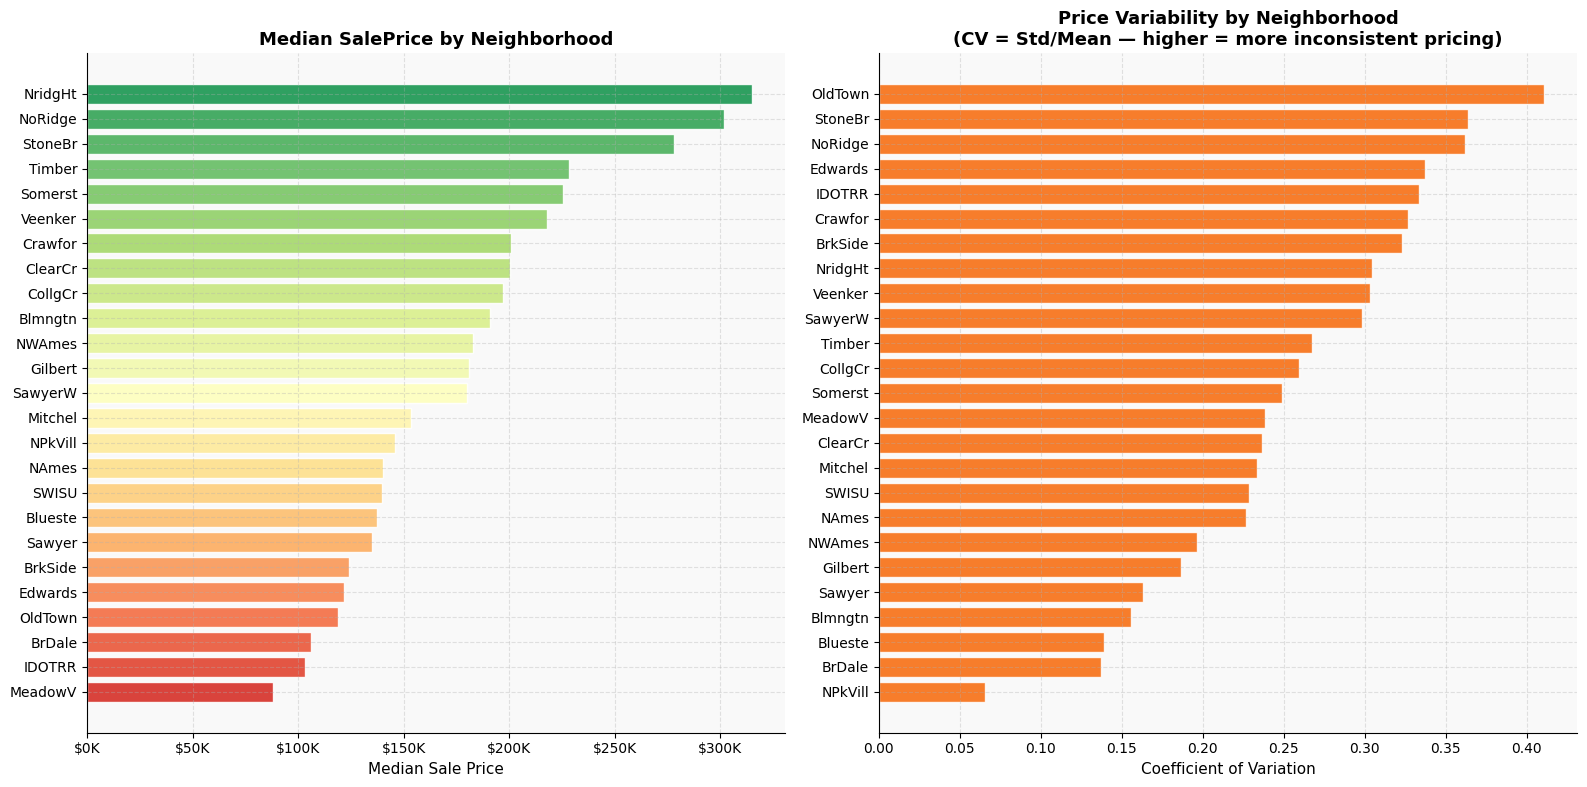

Top 5 most expensive neighborhoods: ['NridgHt', 'NoRidge', 'StoneBr', 'Timber', 'Somerst']
Top 5 most variable neighborhoods: ['OldTown', 'StoneBr', 'NoRidge', 'Edwards', 'IDOTRR']


In [11]:
neigh_stats = train.groupby('Neighborhood')['SalePrice'].agg(['median','mean','std','count'])
neigh_stats.columns = ['Median', 'Mean', 'Std', 'Count']
neigh_stats = neigh_stats.sort_values('Median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Median price by neighborhood
colors_n = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(neigh_stats)))
axes[0].barh(neigh_stats.index[::-1], neigh_stats['Median'][::-1],
             color=colors_n, edgecolor='white', alpha=0.9)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].set_title('Median SalePrice by Neighborhood')
axes[0].set_xlabel('Median Sale Price')

# Price variability (Std/Mean = CV) — which neighborhoods have most variance?
neigh_stats['CV'] = neigh_stats['Std'] / neigh_stats['Mean']
cv_sorted = neigh_stats['CV'].sort_values(ascending=False)
axes[1].barh(cv_sorted.index[::-1], cv_sorted.values[::-1],
             color=C[1], edgecolor='white', alpha=0.85)
axes[1].set_title('Price Variability by Neighborhood\n(CV = Std/Mean — higher = more inconsistent pricing)')
axes[1].set_xlabel('Coefficient of Variation')

plt.tight_layout()
plt.savefig('../plots/08_neighborhood_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 most expensive neighborhoods:', list(neigh_stats.head(5).index))
print('Top 5 most variable neighborhoods:',  list(cv_sorted.head(5).index))

## 8. Time Trends

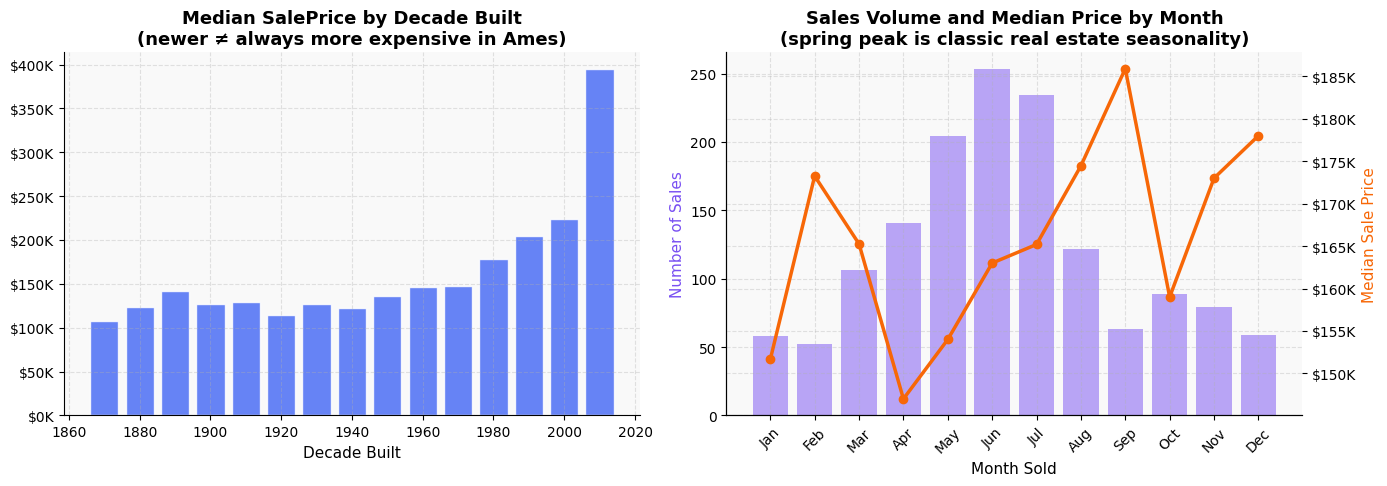

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price by decade built
train['DecadeBuilt'] = (train['YearBuilt'] // 10) * 10
decade_med = train.groupby('DecadeBuilt')['SalePrice'].median()
axes[0].bar(decade_med.index, decade_med.values, width=8, color=C[0], edgecolor='white', alpha=0.85)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].set_xlabel('Decade Built')
axes[0].set_title('Median SalePrice by Decade Built\n(newer ≠ always more expensive in Ames)')

# Monthly sales volume and average price
monthly = train.groupby('MoSold').agg({'SalePrice': ['median', 'count']}).reset_index()
monthly.columns = ['Month', 'MedianPrice', 'Count']
ax2b = axes[1].twinx()
axes[1].bar(monthly['Month'], monthly['Count'], color=C[4], alpha=0.5, label='Volume')
ax2b.plot(monthly['Month'], monthly['MedianPrice'], color=C[1], lw=2.5, marker='o', label='Median Price')
axes[1].set_xlabel('Month Sold')
axes[1].set_ylabel('Number of Sales', color=C[4])
ax2b.set_ylabel('Median Sale Price', color=C[1])
ax2b.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].set_title('Sales Volume and Median Price by Month\n(spring peak is classic real estate seasonality)')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

plt.tight_layout()
plt.savefig('../plots/09_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Key EDA Findings

### Target variable
- SalePrice is **right-skewed** (skew=1.88) - log-transformation brings it close to normal, which is critical for linear models and helps tree-based models too.
- Price ranges from $34,900 to $755,000 with a median of $163,000.

### Missing values
- Most 'missing' values are **not truly missing** - `PoolQC`, `Alley`, `Fence` etc. mean the feature simply doesn't exist. These get filled with 'None' / 0.
- **`LotFrontage`** is genuinely missing (~18%) and should be imputed by neighborhood median rather than global median.

### Key predictors
- **`OverallQual`** (r=0.79) is by far the strongest single predictor - a 1-point increase in quality rating adds roughly $20K–30K.
- **`GrLivArea`**, **`TotalBsmtSF`**, **`GarageArea`** are the top area-based predictors.
- **Neighborhood** is highly impactful - `NridgHt` median is 3× the median of `MeadowV`.

### Outliers
- Two observations with `GrLivArea > 4000` and `SalePrice < $200K` appear to be partial sales/non-arms-length transactions. The Kaggle notes recommend removing them.

### Multicollinearity
- `GarageCars` and `GarageArea` (r=0.88) contain redundant information.
- `TotRmsAbvGrd` and `GrLivArea` (r=0.83) similarly.
- Feature engineering (aggregating these) will help.

### Seasonality
- Spring/summer sales peak (May–July) but prices are relatively stable across months — volume seasonality more than price seasonality.